# MTPA Neural Network Training — PyTorch

기존 코드의 셀 순서, 변수명, 모델과 학습 루프를 유지하면서 온도 입력을 추가했습니다.

- 하나의 Excel 파일에서 Temp1, Temp2, Temp3 시트를 읽습니다. 온도 설정은 각각 25°C, 45°C, 65°C입니다.
- 입력: 토크와 온도 (`IDX_X = [2, 3]`), 출력: Id와 Iq (`IDX_Y = [0, 1]`)
- 세 온도를 합친 뒤 무작위 Train/Test `60% / 40%` 분할, 하나의 모델로 학습
- 모델: `2 → 20 → 2`, 은닉층 ReLU, Dropout은 기존처럼 주석 처리
- 입력/출력 정규화: `MINMAX`, Test에는 Train의 정규화 파라미터 재사용
- Adam, 초기 학습률 `0.004`, 매 epoch `0.999` 배 감쇠
- 기존 정규화 항 유지: `0.00001 × Σ||parameter||₂` (weight와 bias 포함, 제곱합 방식과 다름)
- Batch size: `16`, Epoch: `400`, 무작위 seed: `42`
- 시작 그래프는 세 온도를 한 그래프에 겹쳐 표시하고, Test 결과는 온도별로 평가
- 결과: `results/with_temperature`에 모델, 그래프 및 CSV 저장

현재 CSV에는 시트가 없으므로, 실행 전에 DATA_EXCEL_PATH에 세 시트가 들어 있는 Excel 원본 경로를 지정하세요.
아래 셀을 위에서부터 순서대로 실행하세요.


In [61]:
# 1. 라이브러리 불러오기 및 결과 폴더 생성

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from IPython.display import display
import subprocess

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
REPO_ROOT = Path("/content/MTPA_example_copy") if IN_COLAB else Path(r"C:\Users\HP\Documents\Github\MTPA_example")

if IN_COLAB and not REPO_ROOT.exists(): subprocess.run(["git", "clone", "-q", "https://github.com/Jaehoon-Shim/MTPA_example.git", str(REPO_ROOT)], check=True)
if not REPO_ROOT.exists(): raise FileNotFoundError(f"저장소 폴더를 찾을 수 없습니다: {REPO_ROOT}")
RESULTS_DIR = REPO_ROOT / "results" / "with_temperature"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# 실제 Excel 원본 경로로 지정
DATA_EXCEL_PATH = REPO_ROOT / "data" / "MTPA_FEA_v2_wTemp_wDataAug.xlsx"

print(REPO_ROOT, RESULTS_DIR, DATA_EXCEL_PATH, sep="\n")


print('PyTorch version:', torch.__version__)
print('Working DATA_EXCEL_PATH:', os.getcwd())


C:\Users\HP\Documents\Github\MTPA_example
C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature
C:\Users\HP\Documents\Github\MTPA_example\data\MTPA_FEA_v2_wTemp_wDataAug.xlsx
PyTorch version: 2.13.0+cpu
Working DATA_EXCEL_PATH: c:\Users\HP\Documents\GitHub\MTPA_example


In [62]:
# 2. 주요 설정값
# 데이터 경로
# 모델 입출력 및 은닉 노드 수
IN_NUM = 2
HID_NUM = 20
OUT_NUM = 2
# 학습 설정
INITIAL_LR = 0.004
L2_LAMBDA = 0.00001
DECAY_RATE = 0.999
NUM_EPOCHS = 400
BATCH_SIZE = 8
PRINT_INTERVAL = 10
# 데이터 설정
NORM_FOR_X = 'MINMAX'   # None, MINMAX, STD, PU
NORM_FOR_Y = 'MINMAX'     # None, MINMAX, STD, PU
IDX_X = [2, 3]  # 토크, 온도
IDX_Y = [0, 1]
TEST_DATA_RATIO = 0.4
# 재현 가능한 분할이 필요할 때 사용합니다.
RANDOM_SEED = 42
# 저장 경로
TEST_CSV_PATH = os.path.join(RESULTS_DIR, 'test.csv')
MODEL_PATH = os.path.join(RESULTS_DIR, 'model.pt')
STATE_DICT_PATH = os.path.join(RESULTS_DIR, 'model_state_dict.pt')
LOSS_FIG_PATH = os.path.join(RESULTS_DIR, 'training_loss.jpg')
PRED_FIG_PATH = os.path.join(RESULTS_DIR, 'predicted_vs_true.jpg')
PRED_TEST_CSV_PATH = os.path.join(RESULTS_DIR, 'test_prediction.csv')
LOSS_TEST_CSV_PATH = os.path.join(RESULTS_DIR, 'loss_history.csv')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print('Excel path:', DATA_EXCEL_PATH)
print('Excel exists:', os.path.exists(DATA_EXCEL_PATH))

Excel path: C:\Users\HP\Documents\Github\MTPA_example\data\MTPA_FEA_v2_wTemp_wDataAug.xlsx
Excel exists: True


## 정규화 및 역정규화 함수

`MINMAX`, `STD`, `PU`, `None` 방식 제공


In [63]:
# 3. 정규화 / 역정규화 함수
EPS = 1e-6
def normalize(method, data, *params):
    if method == 'MINMAX':
        data = data.values
        if params:
            data_min, data_max = params
        else:
            data_min = np.min(data, axis=0)
            data_max = np.max(data, axis=0)
        normalized_data = (data - data_min) / ((data_max - data_min) + EPS)
        return normalized_data, data_min, data_max
    elif method == 'STD':
        data = data.values
        if params:
            data_mean, data_std = params
        else:
            data_mean = np.mean(data, axis=0)
            data_std = np.std(data, axis=0)
        normalized_data = (data - data_mean) / (data_std + EPS)
        return normalized_data, data_mean, data_std
    elif method == 'PU':
        data = data.values
        if params:
            data_abs_max = params[0]
        else:
            data_abs_max = np.max(np.abs(data), axis=0)
        normalized_data = data / (data_abs_max + EPS)
        return normalized_data, data_abs_max
    elif method == 'None':
        data = data.values
        return data, None
    else:
        raise ValueError(f'Unknown normalization method: {method}')

def denormalize(method, norm_data, *params):
    if method == 'MINMAX':
        data_min, data_max = params
        return norm_data * (data_max - data_min + EPS) + data_min
    elif method == 'STD':
        data_mean, data_std = params
        return norm_data * (data_std + EPS) + data_mean
    elif method == 'PU':
        data_abs_max = params[0]
        return norm_data * (data_abs_max + EPS)
    elif method == 'None':
        return norm_data
    else:
        raise ValueError(f'Unknown denormalization method: {method}')


## 신경망 모델

 `Linear(2, 20) → ReLU → Linear(20, 2)` 구조입니다.

  `Dropout(0.01)` 은 `forward()`에서 선택적으로 사용가능.

In [64]:
# 4. 신경망 모델 정의

class NN(nn.Module):
    def __init__(self, in_num, hid_num, out_num):
        super().__init__()
        self.l1 = nn.Linear(in_num, hid_num)
        self.l2 = nn.Linear(hid_num, hid_num)
        self.l3 = nn.Linear(hid_num, out_num)
        self.dropout = nn.Dropout(0.01)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.l1(x)
        x = self.relu(x)
        #x = self.dropout(x)
        x = self.l2(x)
        x = self.relu(x)
        x = self.l3(x)
        return x
    
model = NN(in_num=IN_NUM, hid_num=HID_NUM, out_num=OUT_NUM)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)

print(model)


NN(
  (l1): Linear(in_features=2, out_features=20, bias=True)
  (l2): Linear(in_features=20, out_features=20, bias=True)
  (l3): Linear(in_features=20, out_features=2, bias=True)
  (dropout): Dropout(p=0.01, inplace=False)
  (relu): ReLU()
)


In [65]:
# 5. Temp1, Temp2, Temp3 데이터 병합 및 입력/출력 열 선택
TEMPERATURES = {'Temp1': 25, 'Temp2': 45, 'Temp3': 65}
# Excel 시트명: Temp1, Temp2, Temp3 / 각 시트의 열 순서: Id, Iq, 토크
if not os.path.exists(DATA_EXCEL_PATH):
    raise FileNotFoundError(
        f'Excel 파일을 찾을 수 없습니다: {DATA_EXCEL_PATH}\n'
        'DATA_EXCEL_PATH를 Temp1, Temp2, Temp3 시트가 들어 있는 원본 파일 경로로 수정하세요.'
    )

temp_sheets = pd.read_excel(DATA_EXCEL_PATH, sheet_name=list(TEMPERATURES), header=None)

data_list = []
for temp_name, temperature in TEMPERATURES.items():
    temp_data = temp_sheets[temp_name].copy()

    temp_data = temp_data.dropna(axis=1, how='all')
    temp_data.columns = ['y1', 'y2', 'x']
    temp_data['temp'] = temperature
    temp_data['temp_name'] = temp_name
    data_list.append(temp_data)
    print(f'{temp_name} ({temperature} C): {len(temp_data)} samples')

data = pd.concat(data_list, ignore_index=True)

x_data = pd.DataFrame(data.iloc[:, IDX_X])
y_data = pd.DataFrame(data.iloc[:, IDX_Y])

# 숫자가 아닌 값 또는 결측값이 포함된 행 제거
combined = pd.concat([x_data, y_data], axis=1).apply(pd.to_numeric, errors='coerce').dropna()
x_data = combined.iloc[:, :len(IDX_X)].copy()
y_data = combined.iloc[:, len(IDX_X):].copy()

data.to_csv(os.path.join(RESULTS_DIR, 'combined_data.csv'), index=False)
print('전체 데이터 형상:', data.shape)
print('사용 데이터 개수:', len(x_data))
print('입력 열:', data.columns[IDX_X].tolist())
print('출력 열:', data.columns[IDX_Y].tolist())
display(combined.head())


Temp1 (25 C): 265 samples
Temp2 (45 C): 265 samples
Temp3 (65 C): 265 samples
전체 데이터 형상: (795, 5)
사용 데이터 개수: 795
입력 열: ['x', 'temp']
출력 열: ['y1', 'y2']


,x,temp,y1,y2
0,0.000000,25,0.000000,0
1,0.000000,25,0.000000,0
2,0.000000,25,0.000000,0
3,0.000000,25,0.000000,0
4,0.957858,25,-0.002782,1


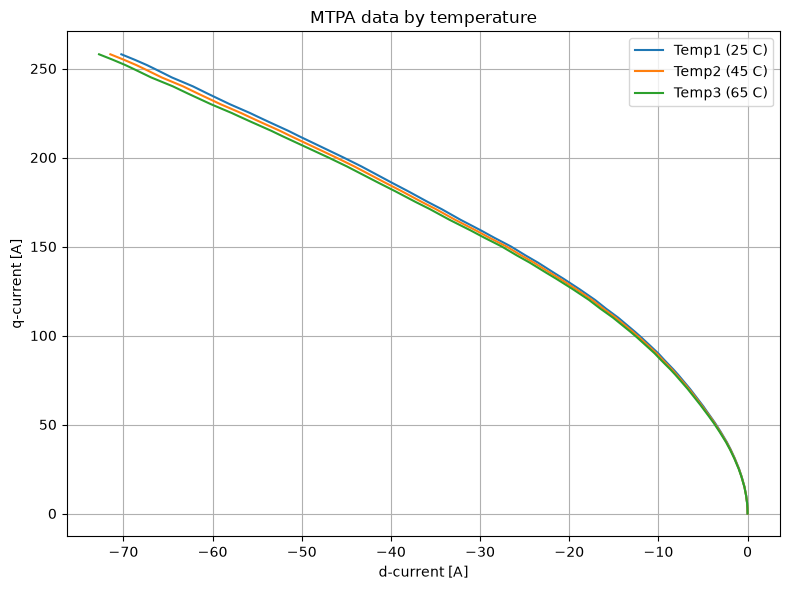

In [66]:
# 5-1. 학습 전 세 온도의 MTPA 데이터를 한 그래프에 겹쳐 표시
plt.figure(figsize=(8, 6))
for temp_name, temperature in TEMPERATURES.items():
    temp_data = data[data['temp_name'] == temp_name].sort_values('x')
    plt.plot(temp_data['y1'], temp_data['y2'], label=f'{temp_name} ({temperature} C)')

plt.xlabel('d-current [A]')
plt.ylabel('q-current [A]')
plt.title('MTPA data by temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'initial_temperature_overlay.png'), dpi=180, bbox_inches='tight')
plt.show()


In [67]:
# 6. Train/Test 무작위 분할 —  60% / 40%

data_length = len(x_data)
last_index = data_length - 1
indices = np.arange(data_length)
test_length = int(data_length * TEST_DATA_RATIO)

np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)
test_indices = np.sort(indices[:test_length])
# Test에 0번 행을 강제로 추가하지 않습니다. Train과의 중복을 방지합니다.

train_indices = np.sort(indices[test_length:])
# Data augmentation
# train_indices = np.insert(train_indices, 0, [0] * 12)
# train_indices = np.append(train_indices, [last_index] * 12)

x_tr = x_data.iloc[train_indices]
x_te = x_data.iloc[test_indices]
y_tr = y_data.iloc[train_indices]
y_te = y_data.iloc[test_indices]

print('Train samples:', len(train_indices))
print('Test samples :', len(test_indices))
print('Train ratio  :', len(train_indices) / data_length)
print('Test ratio   :', len(test_indices) / data_length)
print(train_indices)
# 온도별 샘플 개수 확인
for temp_name, temperature in TEMPERATURES.items():
    train_count = (x_tr['temp'] == temperature).sum()
    test_count = (x_te['temp'] == temperature).sum()
    print(f'{temp_name}: Train {train_count}, Test {test_count}')


Train samples: 477
Test samples : 318
Train ratio  : 0.6
Test ratio   : 0.4
[  0   1   3   4   5   8   9  12  13  14  15  16  17  19  20  21  22  25
  26  27  32  34  35  36  37  38  40  45  46  47  48  50  52  53  57  58
  59  62  64  68  71  75  80  85  87  88  91  93  94  95  98  99 100 102
 103 105 106 107 111 112 113 115 116 117 119 121 122 123 124 125 126 127
 128 129 130 134 138 141 142 143 144 146 147 149 150 151 152 153 154 156
 157 159 160 161 162 166 169 170 171 172 173 175 179 180 183 184 185 186
 187 188 189 190 191 194 195 197 200 201 202 203 205 206 207 214 216 217
 219 221 222 224 225 226 228 229 230 232 233 236 237 238 240 241 242 243
 245 246 249 251 252 253 255 256 257 258 261 262 263 267 268 269 270 271
 272 273 274 276 277 278 279 280 282 283 284 287 288 289 293 295 297 298
 301 303 304 305 307 308 310 312 313 315 317 318 320 321 322 324 325 330
 334 337 339 340 341 342 343 345 347 348 349 353 354 358 359 361 364 366
 369 370 371 372 373 374 376 378 379 383 384 385

## 데이터 정규화

Train에서 구한 정규화 파라미터를 Test에도 사용합니다. 기존 `normalize()`에 `*params`만 추가했습니다.


In [68]:
# 7. 정규화, Tensor 변환 및 DataLoader 생성

x_tr_norm, *x_params = normalize(NORM_FOR_X, x_tr)
x_te_norm, *x_te_params = normalize(NORM_FOR_X, x_te, *x_params)
y_tr_norm, *y_params = normalize(NORM_FOR_Y, y_tr)
y_te_norm, *y_te_params = normalize(NORM_FOR_Y, y_te, *y_params)

print('Train 입력 정규화 파라미터:', x_params)
print('Test 입력 정규화 파라미터 :', x_te_params)
print('Train 출력 정규화 파라미터:', y_params)
print('Test 출력 정규화 파라미터 :', y_te_params)

x_tr_norm = torch.tensor(x_tr_norm, dtype=torch.float32)
x_te_norm = torch.tensor(x_te_norm, dtype=torch.float32)
y_tr_norm = torch.tensor(y_tr_norm, dtype=torch.float32)
y_te_norm = torch.tensor(y_te_norm, dtype=torch.float32)

train_dataset = TensorDataset(x_tr_norm, y_tr_norm)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(x_te_norm, y_te_norm)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('x_train tensor:', x_tr_norm.shape)
print('y_train tensor:', y_tr_norm.shape)
print('x_test tensor :', x_te_norm.shape)
print('y_test tensor :', y_te_norm.shape)


Train 입력 정규화 파라미터: [array([ 0., 25.]), array([262.35,  65.  ])]
Test 입력 정규화 파라미터 : [array([ 0., 25.]), array([262.35,  65.  ])]
Train 출력 정규화 파라미터: [array([-72.73131268,   0.        ]), array([  0., 258.])]
Test 출력 정규화 파라미터 : [array([-72.73131268,   0.        ]), array([  0., 258.])]
x_train tensor: torch.Size([477, 2])
y_train tensor: torch.Size([477, 2])
x_test tensor : torch.Size([318, 2])
y_test tensor : torch.Size([318, 2])


## 모델 학습

각 epoch에서 학습률을 `INITIAL_LR × DECAY_RATE^epoch`으로 직접 갱신하며, 손실함수는 MSE와 수동 L2 정규화 항의 합입니다.

정규화 항은 원본의 `torch.norm(param, p=2)` 계산을 그대로 유지합니다.


In [69]:
# 8. 모델 학습
train_losses = []
test_losses = []
lr_history = []

for epoch in range(NUM_EPOCHS):
    # Adaptive learning rate: initial_lr * decay_rate^epoch
    lr = INITIAL_LR * (DECAY_RATE ** epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    lr_history.append(lr)
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        pred = model(batch_x)
        # Reconstruction loss
        loss = criterion(pred, batch_y)
        # L2 regularization
        l2_reg = torch.tensor(0.0)
        for param in model.parameters():
            l2_reg = l2_reg + torch.norm(param, p=2)
        loss = loss + L2_LAMBDA * l2_reg
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)

    train_losses.append(epoch_loss / len(train_loader.dataset))

    # Test loss에는 L2 항을 포함하지 않음
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            pred = model(batch_x)
            batch_loss = criterion(pred, batch_y)
            test_loss += batch_loss.item() * batch_x.size(0)

    test_losses.append(test_loss / len(test_loader.dataset))

    if (epoch + 1) % PRINT_INTERVAL == 0:
        print(
            f'Epoch [{epoch + 1}/{NUM_EPOCHS}], '
            f'Train Loss: {train_losses[-1]:.6f}, '
            f'Test Loss: {test_losses[-1]:.6f}, '
            f'LR: {lr:.8f}'
        )


Epoch [10/400], Train Loss: 0.000196, Test Loss: 0.000102, LR: 0.00396414
Epoch [20/400], Train Loss: 0.000135, Test Loss: 0.000053, LR: 0.00392468
Epoch [30/400], Train Loss: 0.000129, Test Loss: 0.000039, LR: 0.00388561
Epoch [40/400], Train Loss: 0.000166, Test Loss: 0.000082, LR: 0.00384693
Epoch [50/400], Train Loss: 0.000157, Test Loss: 0.000139, LR: 0.00380863
Epoch [60/400], Train Loss: 0.000144, Test Loss: 0.000043, LR: 0.00377072
Epoch [70/400], Train Loss: 0.000122, Test Loss: 0.000045, LR: 0.00373318
Epoch [80/400], Train Loss: 0.000114, Test Loss: 0.000030, LR: 0.00369601
Epoch [90/400], Train Loss: 0.000159, Test Loss: 0.000180, LR: 0.00365922
Epoch [100/400], Train Loss: 0.000147, Test Loss: 0.000037, LR: 0.00362279
Epoch [110/400], Train Loss: 0.000126, Test Loss: 0.000069, LR: 0.00358673
Epoch [120/400], Train Loss: 0.000171, Test Loss: 0.000019, LR: 0.00355102
Epoch [130/400], Train Loss: 0.000105, Test Loss: 0.000017, LR: 0.00351567
Epoch [140/400], Train Loss: 0.000

In [70]:
# 9. 모델 저장

# 전체 모델 저장
model.eval()
torch.save(model, MODEL_PATH)

# 재사용 편의를 위한 state_dict도 추가 저장
checkpoint = {
    'model_state_dict': model.state_dict(),
    'in_num': IN_NUM,
    'hid_num': HID_NUM,
    'out_num': OUT_NUM,
    'norm_for_x': NORM_FOR_X,
    'norm_for_y': NORM_FOR_Y,
    'x_params': x_params,
    'y_params': y_params,
    'idx_x': IDX_X,
    'idx_y': IDX_Y,
}
torch.save(checkpoint, STATE_DICT_PATH)

print('전체 모델 저장:', MODEL_PATH)
print('체크포인트 저장:', STATE_DICT_PATH)


전체 모델 저장: C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\model.pt
체크포인트 저장: C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\model_state_dict.pt


In [71]:
# 10. Test 데이터 예측, 역정규화 및 실제 스케일 MSE 계산

model.eval()

with torch.no_grad():
    pred = model(x_te_norm).cpu().numpy()

    y_te_pred = denormalize(NORM_FOR_Y, pred, *y_params)
    y_te_real = y_te.values

    test_loss_scaled = criterion(
        torch.tensor(y_te_pred, dtype=torch.float32),
        torch.tensor(y_te_real, dtype=torch.float32)
    )

print(f'Scaled Test Loss (MSE): {test_loss_scaled.item():.6f}')
print('실제값 예시:')
print(y_te_real[:5])
print('예측값 예시:')
print(y_te_pred[:5])



Scaled Test Loss (MSE): 0.142377
실제값 예시:
[[ 0.         0.       ]
 [-0.0133451  3.       ]
 [-0.0261274  4.       ]
 [-0.083209   7.       ]
 [-0.10786    8.       ]]
예측값 예시:
[[0.68769908 0.45817977]
 [0.46299226 3.36465415]
 [0.38808131 4.33359108]
 [0.16314039 7.24307185]
 [0.0881254  8.21345046]]


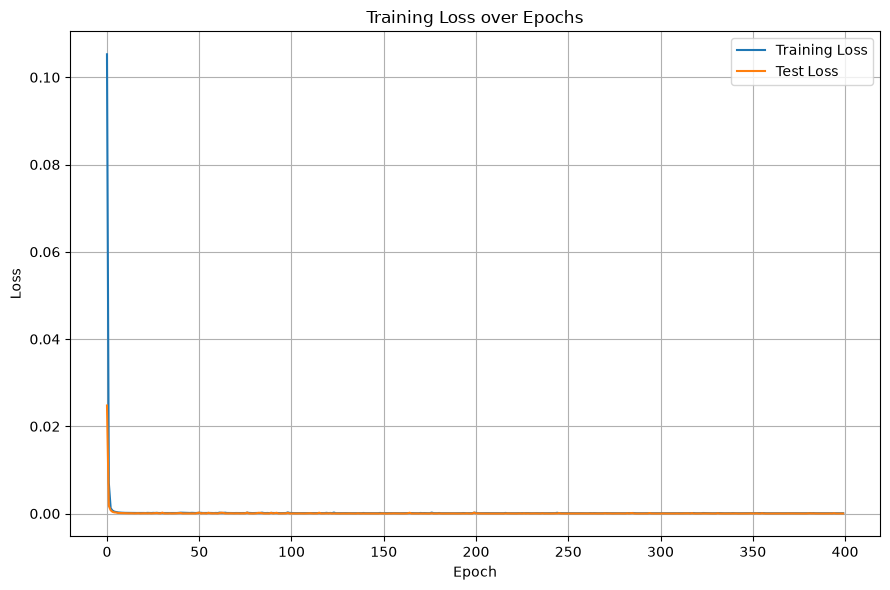

Loss figure saved: C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\training_loss.jpg
Loss CSV saved   : C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\loss_history.csv


In [72]:
# 11. Epoch별 Train/Test loss 그래프 및 CSV 저장

loss_history = pd.DataFrame({
    'epoch': np.arange(1, NUM_EPOCHS + 1),
    'learning_rate': lr_history,
    'train_loss': train_losses,
    'test_loss': test_losses,
})
loss_history.to_csv(LOSS_TEST_CSV_PATH, index=False)

plt.figure(figsize=(9, 6))
plt.plot(range(NUM_EPOCHS), train_losses, label='Training Loss')
plt.plot(range(NUM_EPOCHS), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print('Loss figure saved:', LOSS_FIG_PATH)
print('Loss CSV saved   :', LOSS_TEST_CSV_PATH)


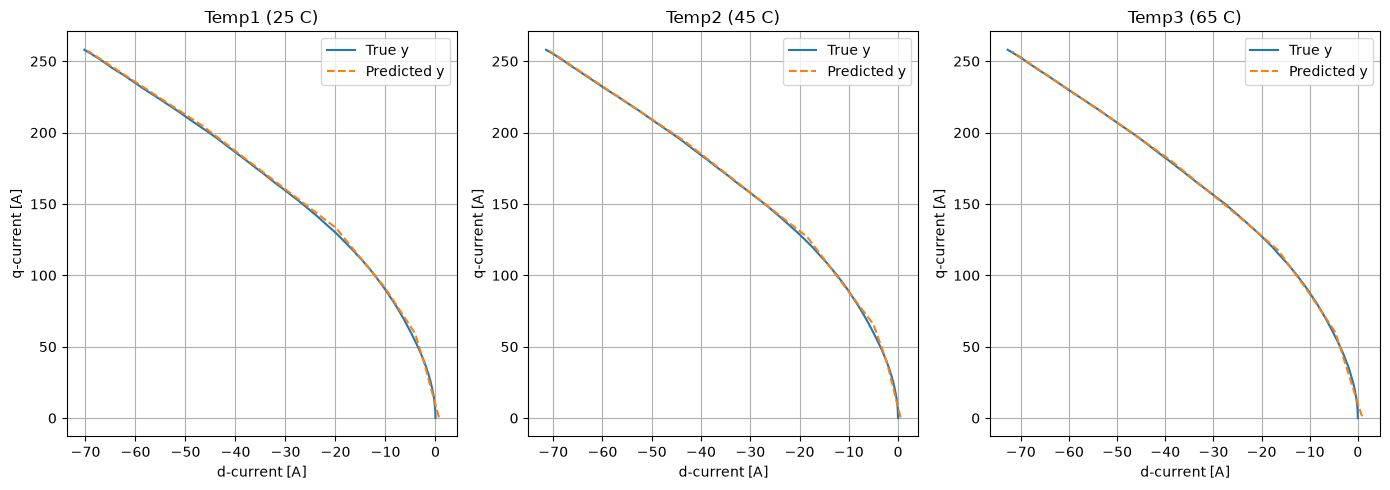

Prediction figure saved: C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\predicted_vs_true.jpg


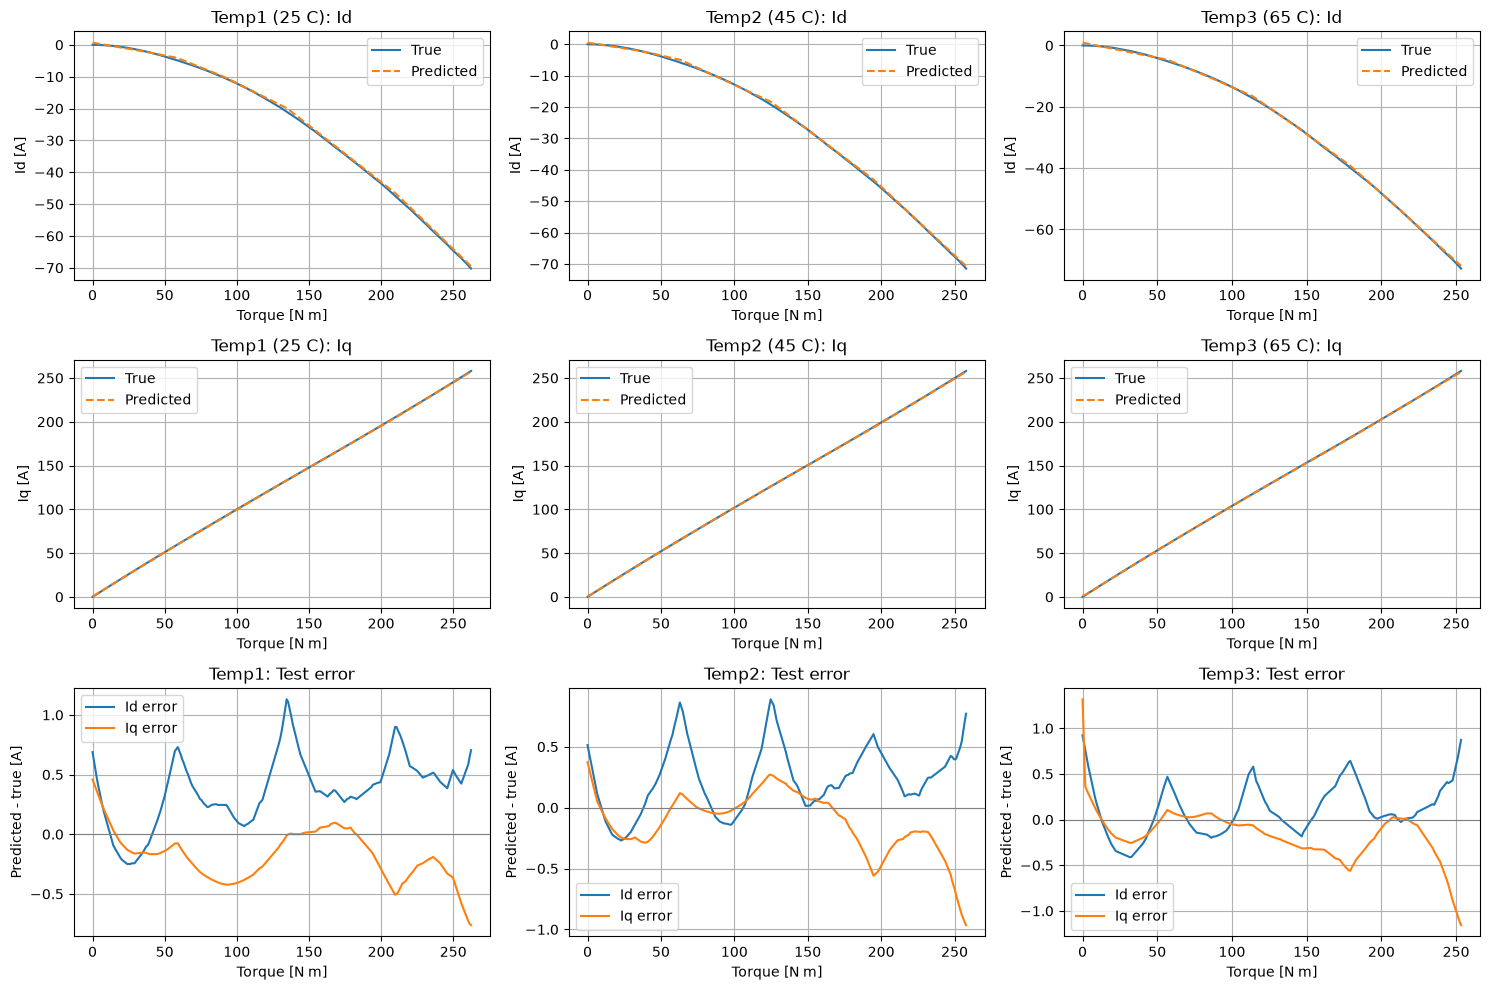

In [73]:
# 12. 온도별 MTPA 실제값과 예측값 비교 그래프 저장
plt.figure(figsize=(14, 5))
for i, (temp_name, temperature) in enumerate(TEMPERATURES.items()):
    temp_indices = np.flatnonzero(x_te['temp'].values == temperature)
    temp_indices = temp_indices[np.argsort(x_te['x'].values[temp_indices])]

    plt.subplot(1, 3, i + 1)
    plt.plot(y_te_real[temp_indices, 0], y_te_real[temp_indices, 1], label='True y')
    plt.plot(y_te_pred[temp_indices, 0], y_te_pred[temp_indices, 1], linestyle='--', label='Predicted y')
    plt.title(f'{temp_name} ({temperature} C)')
    plt.xlabel('d-current [A]')
    plt.ylabel('q-current [A]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.savefig(PRED_FIG_PATH, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'test_mtpa_by_temperature.png'), dpi=180, bbox_inches='tight')
plt.show()
print('Prediction figure saved:', PRED_FIG_PATH)

# 온도별 토크에 따른 Id/Iq 피팅과 오차
plt.figure(figsize=(15, 10))
for i, (temp_name, temperature) in enumerate(TEMPERATURES.items()):
    temp_indices = np.flatnonzero(x_te['temp'].values == temperature)
    temp_indices = temp_indices[np.argsort(x_te['x'].values[temp_indices])]
    torque = x_te['x'].values[temp_indices]
    for j, target in enumerate(['Id', 'Iq']):
        plt.subplot(3, 3, j * 3 + i + 1)
        plt.plot(torque, y_te_real[temp_indices, j], label='True')
        plt.plot(torque, y_te_pred[temp_indices, j], linestyle='--', label='Predicted')
        plt.title(f'{temp_name} ({temperature} C): {target}')
        plt.xlabel('Torque [N m]')
        plt.ylabel(f'{target} [A]')
        plt.grid(True)
        plt.legend()

    plt.subplot(3, 3, i + 7)
    plt.plot(torque, y_te_pred[temp_indices, 0] - y_te_real[temp_indices, 0], label='Id error')
    plt.plot(torque, y_te_pred[temp_indices, 1] - y_te_real[temp_indices, 1], label='Iq error')
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.title(f'{temp_name}: Test error')
    plt.xlabel('Torque [N m]')
    plt.ylabel('Predicted - true [A]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test_fitting_by_temperature.png'), dpi=180, bbox_inches='tight')
plt.show()


In [74]:
# 13. Test 예측 결과 CSV 저장
prediction_df = pd.DataFrame({
    'original_index': test_indices,
    'x_original': x_te.values[:, 0],
    'temperature_C': x_te.values[:, 1],
    'temp_name': data.iloc[test_indices]['temp_name'].values,
    'y1_true': y_te_real[:, 0],
    'y2_true': y_te_real[:, 1],
    'y1_pred': y_te_pred[:, 0],
    'y2_pred': y_te_pred[:, 1],
})

prediction_df.to_csv(PRED_TEST_CSV_PATH, index=False)
display(prediction_df.head())

print('Prediction CSV saved:', PRED_TEST_CSV_PATH)

for temp_name in TEMPERATURES:
    temp_prediction = prediction_df[prediction_df['temp_name'] == temp_name]
    temp_prediction.to_csv(os.path.join(RESULTS_DIR, f'test_prediction_{temp_name}.csv'), index=False)


,original_index,x_original,temperature_C,temp_name,y1_true,y2_true,y1_pred,y2_pred
0,2,0.00000,25.0,Temp1,0.000000,0.0,0.687699,0.458180
1,6,2.87364,25.0,Temp1,-0.013345,3.0,0.462992,3.364654
2,7,3.83163,25.0,Temp1,-0.026127,4.0,0.388081,4.333591
3,10,6.70824,25.0,Temp1,-0.083209,7.0,0.163140,7.243072
4,11,7.66766,25.0,Temp1,-0.107860,8.0,0.088125,8.213450


Prediction CSV saved: C:\Users\HP\Documents\Github\MTPA_example\results\with_temperature\test_prediction.csv


In [75]:
# ============================================================
# 14. 결과 CSV, 학습 이력 CSV, PyTorch 모델(.pt) 저장
# ============================================================


model_cpu = model.to('cpu')
model_cpu.eval()

torch.save(
    model_cpu.state_dict(),
    os.path.join(RESULTS_DIR, 'model_weights.pt')
)

print('Train 입력 정규화 파라미터:', x_params)
print('Test 입력 정규화 파라미터 :', x_te_params)
print('Train 출력 정규화 파라미터:', y_params)
print('Test 출력 정규화 파라미터 :', y_te_params)



Train 입력 정규화 파라미터: [array([ 0., 25.]), array([262.35,  65.  ])]
Test 입력 정규화 파라미터 : [array([ 0., 25.]), array([262.35,  65.  ])]
Train 출력 정규화 파라미터: [array([-72.73131268,   0.        ]), array([  0., 258.])]
Test 출력 정규화 파라미터 : [array([-72.73131268,   0.        ]), array([  0., 258.])]
